# 03. Feature engineering

**Objective.** Define the engineered features, check that each one uses only information available at application time, and measure how much signal each carries.

**Business question.** Do affordability ratios and the applicant's past behaviour with lenders (bureau records, earlier Home Credit applications, instalment payments) tell us anything the raw application does not?

**Why this analysis is needed.** These 25 features are candidates. Some will not earn a place, and Phase 6 will decide that with model results. Here each one gets a formula, a meaning, a leakage check, and a first look at its signal on the **training split only**.

*Educational project. Not a lending policy.*

## The candidate features

**Affordability and profile (from the application table, `src/features.py`).**

| Feature | Formula | Business meaning |
|---|---|---|
| `AGE_YEARS` | -DAYS_BIRTH / 365.25 | Age in readable units; same information as DAYS_BIRTH |
| `CREDIT_INCOME_RATIO` | AMT_CREDIT / AMT_INCOME_TOTAL | Loan size relative to income |
| `ANNUITY_INCOME_RATIO` | AMT_ANNUITY / AMT_INCOME_TOTAL | Share of income taken by each repayment |
| `CREDIT_ANNUITY_RATIO` | AMT_CREDIT / AMT_ANNUITY | Number of annuity payments if there were no interest; a rough proxy for term |
| `EMPLOYED_AGE_SHARE` | DAYS_EMPLOYED / DAYS_BIRTH | Fraction of life spent in the current job |
| `INCOME_PER_FAMILY_MEMBER` | AMT_INCOME_TOTAL / CNT_FAM_MEMBERS | Income available per household member |

**Bureau history (`src/history.py`, one row per applicant).**

| Feature | Meaning |
|---|---|
| `BUREAU_CREDIT_COUNT`, `BUREAU_ACTIVE_COUNT` | Number of credits on record, and how many are active |
| `BUREAU_OVERDUE_COUNT`, `BUREAU_MAX_DAYS_OVERDUE` | Credits currently overdue, and the worst overdue period |
| `BUREAU_DEBT_SUM`, `BUREAU_CREDIT_SUM` | Total current debt and total credit amount |
| `BUREAU_DEBT_TO_CREDIT` | Debt / credit amount: how much of the credit is still owed |
| `BUREAU_HISTORY_DAYS` | Days since the oldest credit was taken out (credit history length) |

**Previous Home Credit applications.**

| Feature | Meaning |
|---|---|
| `PREV_APP_COUNT`, `PREV_APPROVED_COUNT`, `PREV_REFUSED_COUNT` | Earlier applications, approved and refused |
| `PREV_REFUSED_SHARE` | Refused / all earlier applications |
| `PREV_DAYS_SINCE_LAST` | Days since the most recent earlier decision |

**Repayment behaviour on earlier loans (instalments table).**

| Feature | Meaning |
|---|---|
| `INST_PAID_COUNT`, `INST_UNPAID_COUNT` | Instalments with a recorded payment, and those with none |
| `INST_LATE_SHARE`, `INST_MAX_DAYS_LATE` | Share of paid instalments that were late, and the worst delay |
| `INST_UNDERPAID_SHARE` | Share of paid instalments where less than the amount due was paid |
| `INST_PAID_TO_DUE` | Total paid / total due |

## 1. Would this information be known when the loan decision is made?

**Why:** leakage is the main way a credit model looks better than it is. Every history table is dated relative to the application, so the check can be done directly on the raw records.

In [1]:
import sys
sys.path.append("..")

import pandas as pd

from src.analysis import add_missing_category, default_rate_table, mann_whitney_auc
from src.data import load_bureau, load_installments, load_modelling_table, load_previous_applications
from src.features import RATIO_FEATURES
from src.history import HISTORY_FEATURES
from src.plots import apply_style, default_rate_chart

apply_style()
bureau = load_bureau()
previous = load_previous_applications()
installments = load_installments()

print("bureau credits opened after the application (DAYS_CREDIT > 0):", (bureau["DAYS_CREDIT"] > 0).sum())
print("earlier applications decided after this one (DAYS_DECISION > 0):", (previous["DAYS_DECISION"] > 0).sum())
print("instalments due after the application (DAYS_INSTALMENT > 0):", (installments["DAYS_INSTALMENT"] > 0).sum())
print("instalments paid after the application (DAYS_ENTRY_PAYMENT > 0):", (installments["DAYS_ENTRY_PAYMENT"] > 0).sum())
print("instalments with no recorded payment date or amount:",
      (installments["DAYS_ENTRY_PAYMENT"].isna() | installments["AMT_PAYMENT"].isna()).sum())

bureau credits opened after the application (DAYS_CREDIT > 0): 0
earlier applications decided after this one (DAYS_DECISION > 0): 0
instalments due after the application (DAYS_INSTALMENT > 0): 0
instalments paid after the application (DAYS_ENTRY_PAYMENT > 0): 0
instalments with no recorded payment date or amount: 2905


**Result and interpretation.** No record in the three history tables is dated after the application: the counts of positive day values are zero in every check. Every history feature is therefore built only from what was already on file, and the ratio features use only application fields.

**Decision.**
- All 25 features pass the timing test.
- Columns in `previous_application.csv` such as `DAYS_FIRST_DRAWING`, `DAYS_LAST_DUE` and `DAYS_TERMINATION` are not used. They hold placeholder values (365,243) on hundreds of thousands of rows, and dates like a termination date could describe events after the decision. They were not loaded at all.
- Records for applicants who are not in the labelled file (about 15% of the bureau rows) are dropped before aggregating.

## 2. What does "no history" mean?

**Why:** bureau records exist for 85.7% of applicants, earlier applications for 94.6% and instalments for 94.8%. An applicant with no record is different from one with a clean record, and the treatment has to reflect that.

In [2]:
table = load_modelling_table()
train = table[table["split"] == "train"]
target = train["TARGET"]

no_instalments = (train["INST_PAID_COUNT"] + train["INST_UNPAID_COUNT"]) == 0
groups = {
    "no bureau record": train["BUREAU_CREDIT_COUNT"] == 0,
    "no earlier application": train["PREV_APP_COUNT"] == 0,
    "no instalment record": no_instalments,
}
for name, mask in groups.items():
    print(f"{name}: {mask.sum():,} applicants | default {target[mask].mean():.2%} | others {target[~mask].mean():.2%}")

no bureau record: 26,341 applicants | default 10.12% | others 7.73%
no earlier application: 9,870 applicants | default 6.31% | others 8.17%
no instalment record: 9,506 applicants | default 6.31% | others 8.17%


**Result.** Applicants with no bureau record default at 10.12% (26,341 applicants) against 7.73% for the rest. Applicants with no earlier Home Credit application or no instalment record default at 6.31%, against 8.17% for the rest.

**Interpretation.** "No history" does not point one way. Missing bureau data goes with higher risk, while being new to Home Credit goes with lower risk. Treating all gaps as zero, or as bad, would be wrong for at least one of them.

**Decision.**
- Count features (number of credits, applications, instalments) are 0 when there is no record, since that is literally true.
- Ratio and share features stay missing when they cannot be computed. A missing share is not the same as a share of 0.
- Tree models will see the missing values directly. Logistic regression gets an explicit "no record" indicator in Phase 6.

## 3. How much signal does each feature carry?

**Why:** a first, cheap look at which candidates are informative. It is one variable at a time and rank based, so it understates non-monotonic patterns (see notebook 02) and rare events.

The value shown is the Mann-Whitney AUC turned into "power": 0.5 means no ranking ability and higher is better, whichever direction the feature points.

In [3]:
rows = []
for column in RATIO_FEATURES + HISTORY_FEATURES:
    auc = mann_whitney_auc(train[column], target)["auc"]
    rows.append({
        "feature": column,
        "coverage": train[column].notna().mean(),
        "power": max(auc, 1 - auc),
        "higher_value_means": "riskier" if auc > 0.5 else "safer",
    })
signal = pd.DataFrame(rows).sort_values("power", ascending=False)
print(signal.round(3).to_string(index=False))

print()
print("raw columns the ratios are built from:")
for column in ["DAYS_BIRTH", "DAYS_EMPLOYED", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]:
    auc = mann_whitney_auc(train[column], target)["auc"]
    print(f"  {column}: power {max(auc, 1 - auc):.3f}")

                 feature  coverage  power higher_value_means
   BUREAU_DEBT_TO_CREDIT     0.830  0.596            riskier
               AGE_YEARS     1.000  0.584              safer
     BUREAU_HISTORY_DAYS     0.857  0.577              safer
      EMPLOYED_AGE_SHARE     0.820  0.569              safer
         INST_LATE_SHARE     0.948  0.564            riskier
      PREV_REFUSED_SHARE     0.947  0.561            riskier
        INST_PAID_TO_DUE     0.948  0.560              safer
      PREV_REFUSED_COUNT     1.000  0.556            riskier
    INST_UNDERPAID_SHARE     0.948  0.555            riskier
         BUREAU_DEBT_SUM     0.833  0.553            riskier
      INST_MAX_DAYS_LATE     0.948  0.550            riskier
    CREDIT_ANNUITY_RATIO     1.000  0.534              safer
     BUREAU_ACTIVE_COUNT     1.000  0.532            riskier
     PREV_APPROVED_COUNT     1.000  0.525              safer
    PREV_DAYS_SINCE_LAST     0.947  0.524              safer
     BUREAU_CREDIT_COUNT

**Observation.**
- The strongest single features are `BUREAU_DEBT_TO_CREDIT` (0.596), `AGE_YEARS` (0.584), `BUREAU_HISTORY_DAYS` (0.577), `EMPLOYED_AGE_SHARE` (0.569), `INST_LATE_SHARE` (0.564), `PREV_REFUSED_SHARE` (0.561) and `INST_PAID_TO_DUE` (0.560).
- Several ratios add nothing over their raw inputs. `AGE_YEARS` (0.584) matches `DAYS_BIRTH` (0.584) because it is only a rescale. `EMPLOYED_AGE_SHARE` (0.569) is below `DAYS_EMPLOYED` (0.582). `INCOME_PER_FAMILY_MEMBER` (0.517) is no better than raw income (0.521). `CREDIT_INCOME_RATIO` shows 0.503, but notebook 02 showed a real inverted-U pattern that a rank statistic cannot see.
- Rare events score low: `BUREAU_OVERDUE_COUNT` (0.506), `BUREAU_MAX_DAYS_OVERDUE` (0.507) and `INST_UNPAID_COUNT` (0.503) are zero for almost every applicant. That does not mean they carry no information, as the next section shows.

## 4. Do the behaviour features tell a readable story?

**Question:** do applicants who paid earlier instalments late, or who were refused before, default more? A feature should make business sense, not only statistical sense.

        group     n   rate
    None late 81987 0.0681
    1-5% late 24206 0.0687
   5-20% late 46273 0.0942
Over 20% late 22530 0.1194
      Missing  9510 0.0631

     group     n   rate
 Q1 lowest 41968 0.0541
        Q2 19285 0.0593
        Q3 30626 0.0679
        Q4 30626 0.0876
Q5 highest 30627 0.1212
   Missing 31374 0.0958

                 group      n   rate
           Any refusal  60242 0.1033
No earlier application   9870 0.0631
            No refusal 114394 0.0704

bureau credit currently overdue: 2,067 applicants, default 15.48% vs 7.99%


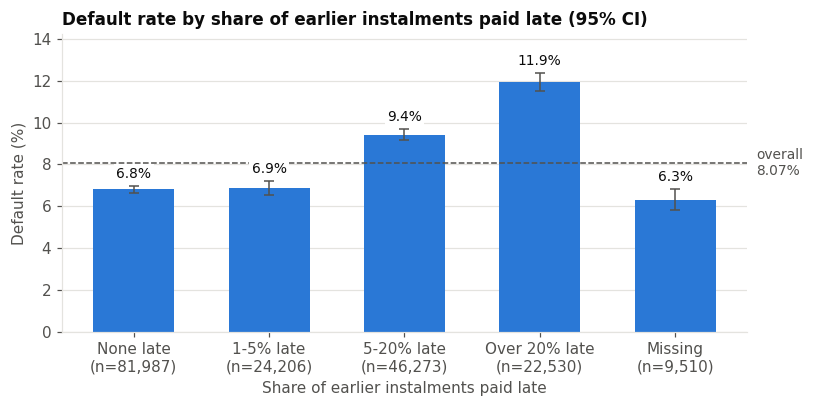

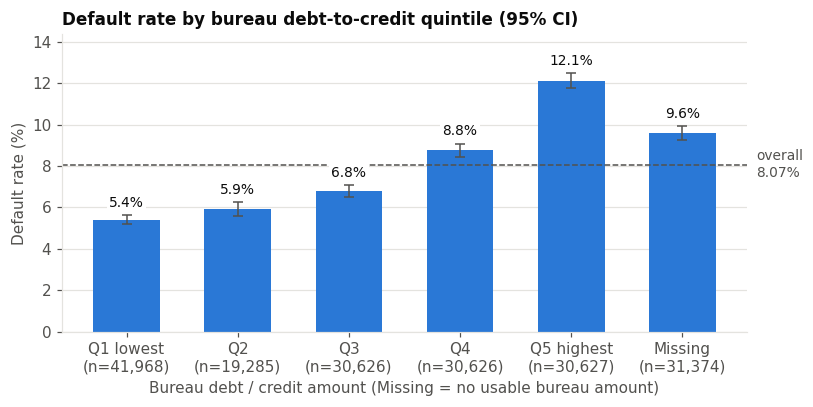

In [4]:
late_bands = pd.cut(train["INST_LATE_SHARE"], [-0.001, 0, 0.05, 0.2, 1.0],
                    labels=["None late", "1-5% late", "5-20% late", "Over 20% late"])
late_summary = default_rate_table(target, add_missing_category(late_bands))
print(late_summary[["group", "n", "rate"]].round(4).to_string(index=False))
fig = default_rate_chart(late_summary, "Default rate by share of earlier instalments paid late (95% CI)",
                         "Share of earlier instalments paid late", target.mean())

labels = ["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"]
debt_bands = add_missing_category(pd.qcut(train["BUREAU_DEBT_TO_CREDIT"], 5, labels=labels, duplicates="drop"))
debt_summary = default_rate_table(target, debt_bands)
print()
print(debt_summary[["group", "n", "rate"]].round(4).to_string(index=False))
fig = default_rate_chart(debt_summary, "Default rate by bureau debt-to-credit quintile (95% CI)",
                         "Bureau debt / credit amount (Missing = no usable bureau amount)", target.mean())

refusal = pd.Series("No refusal", index=train.index)
refusal[train["PREV_REFUSED_COUNT"] > 0] = "Any refusal"
refusal[train["PREV_APP_COUNT"] == 0] = "No earlier application"
print()
print(default_rate_table(target, refusal.astype("category"))[["group", "n", "rate"]].round(4).to_string(index=False))

overdue = train["BUREAU_OVERDUE_COUNT"] > 0
print()
print(f"bureau credit currently overdue: {overdue.sum():,} applicants, default {target[overdue].mean():.2%} vs {target[~overdue].mean():.2%}")

**Observation.**
- Default is 6.81% for applicants who never paid an instalment late, 6.87% for those late on 1-5%, 9.42% for 5-20% and 11.94% for over 20%.
- Default rises steadily with bureau debt-to-credit, from 5.41% in the lowest group to 12.12% in the highest. The quintiles differ in size because many applicants share a ratio of exactly 0.
- Applicants with a previous refusal default at 10.33%, against 7.04% with no refusal.
- Only 2,067 training applicants have a currently overdue bureau credit, but they default at 15.48% against 7.99%.

**Interpretation.** Each behaviour feature points the way a credit analyst would expect, and the three strongest have large gaps between the top and bottom groups. The overdue count is the useful kind of rare feature: small in number, but a strong signal where it applies. It also shows why a low rank-based power (0.506) must not be used to throw such a feature away.

**Caveats.**
- `INST_UNDERPAID_SHARE` may overstate underpayment if an instalment was settled in several payments, each recorded as a separate row. This has not been checked.
- Some bureau debts are negative (777 training applicants), so the debt-to-credit ratio goes below 0 for 760 and above 1 for 917. These are kept: they may be overpayments or data errors, and removing them would be a guess. Tree models are not troubled by them; whether the logistic model needs clipping is decided in Phase 6.
- While building these features, a check found infinite values in `INST_PAID_TO_DUE` for applicants whose instalment amounts summed to zero. They are now set to missing, and a test guards the fix.

## Decisions from this notebook

| Finding | Decision |
|---|---|
| No history record is dated after the application | All 25 features pass the timing test; unsafe placeholder columns were not loaded |
| "No history" means different things for different tables | Counts are 0 when there is no record; shares and ratios stay missing |
| Several ratios add nothing over their raw inputs | Keep them as candidates, but drop any that do not help in the Phase 6 comparison |
| Rare-event features score low on rank power but matter where present | Keep; judge by model results, not by this table |
| Behaviour features tell a sensible story | Keep all three history groups for the "does history help?" test |

**How the alternate-data question will be tested (Phase 6).** Three feature sets are compared on the validation split with the same model: application columns only; plus the engineered ratios; plus the history features. The difference between the second and third is the value of history data. Nothing is claimed about that until the results exist.

## Next step

Phase 6: the baseline (logistic regression) and a small number of candidate models, with class weights compared against no reweighting, all evaluated on the validation split. The test split stays untouched until the final model is chosen.